In [178]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
import pickle
import warnings
warnings.filterwarnings("ignore")

In [179]:
df = pd.read_csv(r"C:\Users\ASUS\Documents\GUVI ZEN CLASSES\MAINT BOOT\singapore Flat resale price predicting\Data File_1\Resale flat prices based on registration date from Jan-2017 onwards.csv")
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [180]:
df.size

2176020

In [181]:
df =df.head(50000)

In [182]:
df.size

550000

In [183]:
df.shape

(50000, 11)

In [184]:
df.duplicated().sum()

188

In [185]:
df.drop_duplicates(inplace=True)

In [186]:
df.duplicated().sum()

0

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49812 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                49812 non-null  object 
 1   town                 49812 non-null  object 
 2   flat_type            49812 non-null  object 
 3   block                49812 non-null  object 
 4   street_name          49812 non-null  object 
 5   storey_range         49812 non-null  object 
 6   floor_area_sqm       49812 non-null  float64
 7   flat_model           49812 non-null  object 
 8   lease_commence_date  49812 non-null  int64  
 9   remaining_lease      49812 non-null  object 
 10  resale_price         49812 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 4.6+ MB


In [188]:
df.head(2)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0


In [189]:
df.drop(columns=['block','street_name','storey_range','flat_model'],inplace=True)

In [190]:
df.head(2)

,month,town,flat_type,floor_area_sqm,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,44.0,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,67.0,1978,60 years 07 months,250000.0


In [191]:
df.isna().sum()

month                  0
town                   0
flat_type              0
floor_area_sqm         0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [192]:
df['remaining_lease'].sample(5)

15842    68 years 10 months
30394     62 years 01 month
16471              94 years
21790     59 years 01 month
42568    93 years 08 months
Name: remaining_lease, dtype: object

In [193]:
def lease_conversion(lease):

    lease = pd.Series(lease)

    extracted = lease.str.extract(r'(\d+)\s*year.*?(\d+)\s*month').fillna(0).astype(int)

    lease_years = extracted[0]+extracted[1]/12
    
    return lease_years

In [194]:
df['remaining_lease'] = df['remaining_lease'].apply(lambda x: lease_conversion(x))

In [195]:
df['remaining_lease']

0        61.333333
1        60.583333
2        62.416667
3        62.083333
4        62.416667
           ...    
49995    82.333333
49996    82.250000
49997    79.166667
49998    82.250000
49999    81.583333
Name: remaining_lease, Length: 49812, dtype: float64

In [196]:
'''def lease_conversion(lease):

    if not isinstance(lease, pd.Series):
        lease = pd.Series(lease)

    extracted = lease.str.extract(r'(\d+)\s*year.*?(\d+)\s*month')

    years = extracted[0].fillna(0).astype(int)

    months= extracted[1].fillna(0).astype(int)

    lease = years+months/12

    return lease'''


"def lease_conversion(lease):\n\n    if not isinstance(lease, pd.Series):\n        lease = pd.Series(lease)\n\n    extracted = lease.str.extract(r'(\\d+)\\s*year.*?(\\d+)\\s*month')\n\n    years = extracted[0].fillna(0).astype(int)\n\n    months= extracted[1].fillna(0).astype(int)\n\n    lease = years+months/12\n\n    return lease"

In [197]:
#df['remaining_lease'] = df['remaining_lease'].apply(lambda x: lease_conversion(x))

In [198]:
#df['remaining_lease']

In [199]:
df.isna().sum()

month                  0
town                   0
flat_type              0
floor_area_sqm         0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [200]:
df.dtypes

month                   object
town                    object
flat_type               object
floor_area_sqm         float64
lease_commence_date      int64
remaining_lease        float64
resale_price           float64
dtype: object

In [201]:
df.head(2)

,month,town,flat_type,floor_area_sqm,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,44.0,1979,61.333333,232000.0
1,2017-01,ANG MO KIO,3 ROOM,67.0,1978,60.583333,250000.0


In [202]:
df['remaining_lease'] = df['remaining_lease'].apply(lambda x:round(x,2))

In [203]:
df['remaining_lease'].head()

0    61.33
1    60.58
2    62.42
3    62.08
4    62.42
Name: remaining_lease, dtype: float64

In [204]:
df['month'] = pd.to_datetime(df['month'],errors='coerce')

In [205]:
df['lease_commence_date'] = pd.to_datetime(df['lease_commence_date'],errors='coerce')

In [206]:
df.dtypes

month                  datetime64[ns]
town                           object
flat_type                      object
floor_area_sqm                float64
lease_commence_date    datetime64[ns]
remaining_lease               float64
resale_price                  float64
dtype: object

In [207]:
df.head(2)

,month,town,flat_type,floor_area_sqm,lease_commence_date,remaining_lease,resale_price
0,2017-01-01,ANG MO KIO,2 ROOM,44.0,1970-01-01 00:00:00.000001979,61.33,232000.0
1,2017-01-01,ANG MO KIO,3 ROOM,67.0,1970-01-01 00:00:00.000001978,60.58,250000.0


In [208]:
df['lease_comm_year'] = df['lease_commence_date'].dt.year

In [209]:
df.head(2)

,month,town,flat_type,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,lease_comm_year
0,2017-01-01,ANG MO KIO,2 ROOM,44.0,1970-01-01 00:00:00.000001979,61.33,232000.0,1970
1,2017-01-01,ANG MO KIO,3 ROOM,67.0,1970-01-01 00:00:00.000001978,60.58,250000.0,1970


In [210]:
df.dtypes

month                  datetime64[ns]
town                           object
flat_type                      object
floor_area_sqm                float64
lease_commence_date    datetime64[ns]
remaining_lease               float64
resale_price                  float64
lease_comm_year                 int32
dtype: object

In [211]:
df['lease_comm_year'] = df['lease_comm_year'].astype('datetime64[ns]')

In [212]:
df['diff'] = df['month'] - df['lease_comm_year']

In [213]:
df.head(2)

,month,town,flat_type,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,lease_comm_year,diff
0,2017-01-01,ANG MO KIO,2 ROOM,44.0,1970-01-01 00:00:00.000001979,61.33,232000.0,1970-01-01 00:00:00.000001970,17166 days 23:59:59.999998030
1,2017-01-01,ANG MO KIO,3 ROOM,67.0,1970-01-01 00:00:00.000001978,60.58,250000.0,1970-01-01 00:00:00.000001970,17166 days 23:59:59.999998030


In [214]:
#df['diff'] = df['diff'].apply(lambda x: timedelta(days=int(x.split()[0])))
df['diff'] = df['diff'].apply(lambda x: x.days)

In [215]:
df.head()

,month,town,flat_type,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,lease_comm_year,diff
0,2017-01-01,ANG MO KIO,2 ROOM,44.0,1970-01-01 00:00:00.000001979,61.33,232000.0,1970-01-01 00:00:00.000001970,17166
1,2017-01-01,ANG MO KIO,3 ROOM,67.0,1970-01-01 00:00:00.000001978,60.58,250000.0,1970-01-01 00:00:00.000001970,17166
2,2017-01-01,ANG MO KIO,3 ROOM,67.0,1970-01-01 00:00:00.000001980,62.42,262000.0,1970-01-01 00:00:00.000001970,17166
3,2017-01-01,ANG MO KIO,3 ROOM,68.0,1970-01-01 00:00:00.000001980,62.08,265000.0,1970-01-01 00:00:00.000001970,17166
4,2017-01-01,ANG MO KIO,3 ROOM,67.0,1970-01-01 00:00:00.000001980,62.42,265000.0,1970-01-01 00:00:00.000001970,17166


In [216]:
df.dtypes

month                  datetime64[ns]
town                           object
flat_type                      object
floor_area_sqm                float64
lease_commence_date    datetime64[ns]
remaining_lease               float64
resale_price                  float64
lease_comm_year        datetime64[ns]
diff                            int64
dtype: object

In [217]:
df['diff'] = pd.to_datetime(df['diff'],errors='coerce')

In [218]:
df['diff'] = df['diff'].astype('int64')

In [219]:
df['diff'] = df['diff'].apply(lambda x:x/30.44)

In [220]:
df['diff'] = df['diff'].apply(lambda x: round(x,2))

In [221]:
df['diff'] 

0        563.93
1        563.93
2        563.93
3        563.93
4        563.93
          ...  
49995    591.85
49996    591.85
49997    591.85
49998    591.85
49999    591.85
Name: diff, Length: 49812, dtype: float64

In [222]:
df['lease_duration'] = df['diff'] + df['remaining_lease']

In [223]:
df['lease_duration'] = df['lease_duration'].apply(lambda x: x/12)

In [224]:
df['lease_duration'] = df['lease_duration'].apply(lambda x: round(x,2))

In [225]:
df['lease_duration'].unique()

array([52.1 , 52.04, 52.2 , 52.17, 46.99, 52.12, 51.85, 51.97, 51.95,
       52.22, 52.06, 51.93, 52.11, 52.02, 52.01, 52.31, 52.08, 52.15,
       51.87, 51.94, 52.24, 52.05, 54.8 , 54.79, 52.  , 54.88, 53.52,
       52.88, 52.27, 52.29, 52.63, 52.13, 52.67, 52.68, 52.64, 52.61,
       52.51, 52.44, 52.78, 51.99, 52.03, 52.76, 52.73, 52.23, 52.35,
       52.5 , 53.92, 54.32, 52.92, 54.69, 51.54, 53.54, 53.9 , 53.27,
       52.54, 53.32, 52.69, 51.64, 52.71, 52.65, 52.75, 52.82, 53.2 ,
       53.19, 52.79, 53.01, 52.59, 52.53, 52.77, 52.57, 52.56, 52.8 ,
       53.67, 52.62, 54.22, 52.95, 52.93, 52.6 , 54.24, 54.23, 53.61,
       52.48, 53.65, 51.45, 51.76, 51.33, 51.29, 51.88, 51.67, 51.47,
       52.38, 51.62, 54.96, 51.58, 54.94, 51.37, 51.77, 53.87, 54.97,
       54.57, 54.31, 53.88, 52.7 , 53.76, 51.7 , 52.45, 52.89, 54.9 ,
       53.68, 53.99, 52.9 , 53.75, 52.87, 53.78, 53.71, 53.73, 53.98,
       53.64, 54.06, 53.74, 54.02, 53.97, 53.77, 53.63, 52.83, 52.86,
       51.68, 52.72,

In [226]:
df.dtypes

month                  datetime64[ns]
town                           object
flat_type                      object
floor_area_sqm                float64
lease_commence_date    datetime64[ns]
remaining_lease               float64
resale_price                  float64
lease_comm_year        datetime64[ns]
diff                          float64
lease_duration                float64
dtype: object

In [227]:
df['remaining_lease'] = df['remaining_lease'].apply(lambda x: x/12)

In [228]:
df['remaining_lease'] = df['remaining_lease'].apply(lambda x:round(x,2))

In [229]:
df.head(2)

,month,town,flat_type,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,lease_comm_year,diff,lease_duration
0,2017-01-01,ANG MO KIO,2 ROOM,44.0,1970-01-01 00:00:00.000001979,5.11,232000.0,1970-01-01 00:00:00.000001970,563.93,52.10
1,2017-01-01,ANG MO KIO,3 ROOM,67.0,1970-01-01 00:00:00.000001978,5.05,250000.0,1970-01-01 00:00:00.000001970,563.93,52.04


In [230]:
df.drop(columns=['month','lease_commence_date','lease_comm_year','diff'],inplace=True)

In [231]:
df.head(2)

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,ANG MO KIO,2 ROOM,44.0,5.11,232000.0,52.10
1,ANG MO KIO,3 ROOM,67.0,5.05,250000.0,52.04


In [232]:
df.dtypes

town                object
flat_type           object
floor_area_sqm     float64
remaining_lease    float64
resale_price       float64
lease_duration     float64
dtype: object

In [233]:
df.isna().sum()

town               0
flat_type          0
floor_area_sqm     0
remaining_lease    0
resale_price       0
lease_duration     0
dtype: int64

In [234]:
df.head(2)

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,ANG MO KIO,2 ROOM,44.0,5.11,232000.0,52.10
1,ANG MO KIO,3 ROOM,67.0,5.05,250000.0,52.04


In [235]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
floor_area_sqm,49812.0,97.92,24.22,31.00,82.00,96.00,113.00,249.00
remaining_lease,49812.0,5.69,1.97,0.00,5.21,5.90,6.89,8.06
resale_price,49812.0,440903.84,154212.12,160000.00,330000.00,408000.00,513000.00,1200000.00
lease_duration,49812.0,53.87,2.08,46.99,53.20,54.21,55.17,57.29


In [236]:
num_cols = df.select_dtypes('number')
num_cols.head(2)

,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,44.0,5.11,232000.0,52.10
1,67.0,5.05,250000.0,52.04


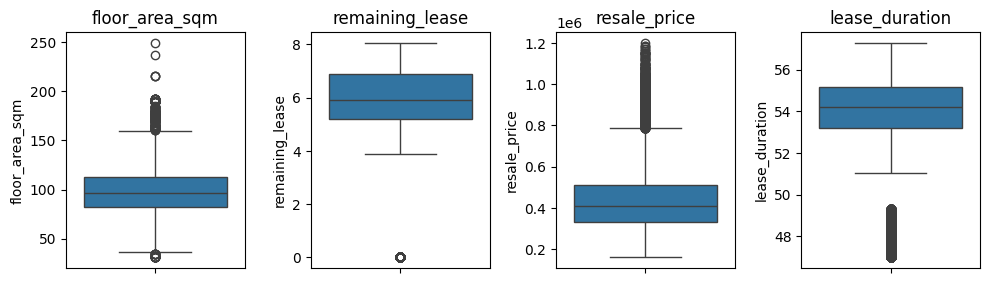

In [237]:
plt.figure(figsize=(10,8))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# floor #

In [238]:
q1 = df['floor_area_sqm'].quantile(0.25)
q3 = df['floor_area_sqm'].quantile(0.75)
iqr = q3 - q1
print(f"Q1 : {q1}, Q3 : {q3}, IQR: {iqr}")

Q1 : 82.0, Q3 : 113.0, IQR: 31.0


In [239]:
lf = q1 - 1.5*iqr
uf = q3 + 1.5*iqr
print(f"Lower_fence : {lf}, Upper_fence : {uf}")

Lower_fence : 35.5, Upper_fence : 159.5


In [240]:
df = df[(df['floor_area_sqm']>lf) & (df['floor_area_sqm']<uf)]

In [241]:
df = df[df['floor_area_sqm']<158]

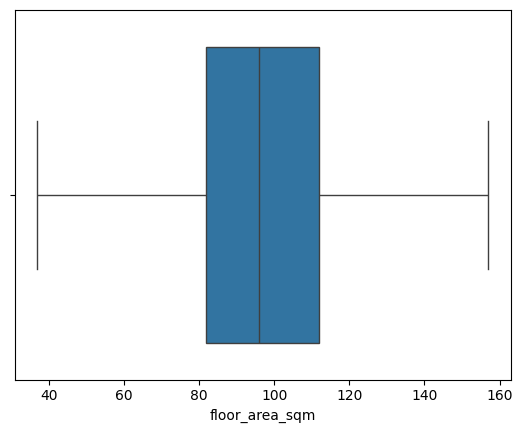

In [242]:
sns.boxplot(data=df,x=df['floor_area_sqm'])
plt.show()

## Resale price ##

In [243]:
q1 = df['resale_price'].quantile(0.25)
q3 = df['resale_price'].quantile(0.75)
iqr = q3 - q1 
print(f"Q1 : {q1}, Q3 : {q3}, IQR : {iqr}")

Q1 : 330000.0, Q3 : 510000.0, IQR : 180000.0


In [244]:
lf = q1 - 1.5*iqr
uf = q3 + 1.5*iqr
print(f"Lower_fence : {lf}, Upper-fence : {uf}")

Lower_fence : 60000.0, Upper-fence : 780000.0


In [245]:
df = df[(df['resale_price']>lf) & (df['resale_price']<uf)]

In [246]:
df = df[df['resale_price']<700000]

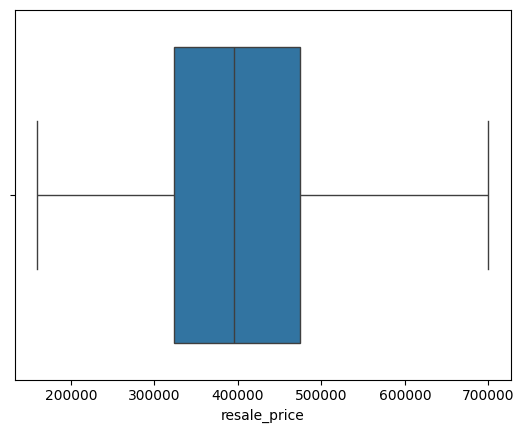

In [247]:
sns.boxplot(data=df,x=df['resale_price'])
plt.show()

## Lease-duration ##

In [248]:
q1 = df['lease_duration'].quantile(0.25)
q3 = df['lease_duration'].quantile(0.75)
iqr = q3 - q1
print(f"Q1 : {q1}, Q3 : {q3}, IQR : {iqr:.2f}")

Q1 : 53.17, Q3 : 55.1, IQR : 1.93


In [249]:
lf = q1 - 1.5 * iqr
uf = q3 + 1.5 * iqr
print(f"Lower_fence : {lf:.2f}, Upper_fence : {uf:.2f}")

Lower_fence : 50.28, Upper_fence : 58.00


In [250]:
df = df[(df['lease_duration']>lf) & (df['lease_duration']<uf)]

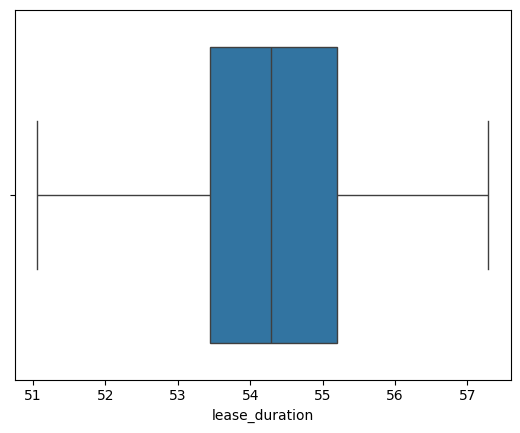

In [251]:
sns.boxplot(data=df,x=df['lease_duration'])
plt.show()

## Remaining_lease ##

In [252]:
q1 = df['remaining_lease'].quantile(0.25)
q3 = df['remaining_lease'].quantile(0.75)
iqr = q3 - q1
print(f"Q1 : {q1}, Q3 : {q3}, IQR : {iqr}")

Q1 : 5.44, Q3 : 6.9, IQR : 1.46


In [253]:
lf = q1 - 1.5 * iqr
uf = q3 + 1.5 * iqr
print(f"Lower_fence : {lf:.2f}, Upper_fence : {uf:.2f}")

Lower_fence : 3.25, Upper_fence : 9.09


In [254]:
df = df[df['remaining_lease']>1.0]

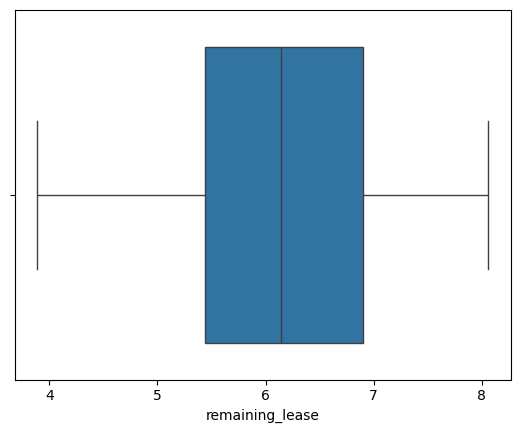

In [255]:
sns.boxplot(data=df,x=df['remaining_lease'])
plt.show()

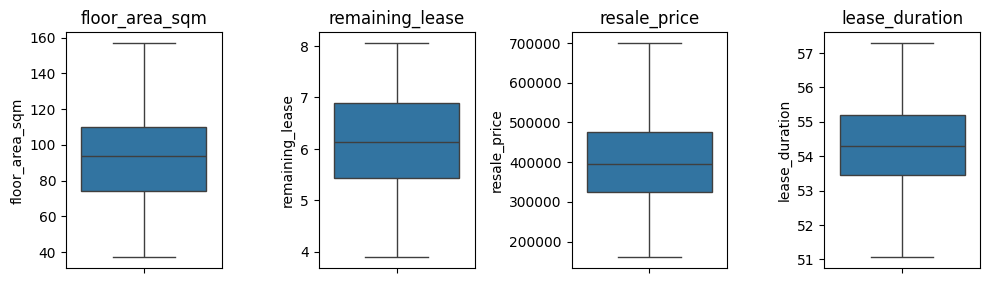

In [256]:
plt.figure(figsize=(10,8))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

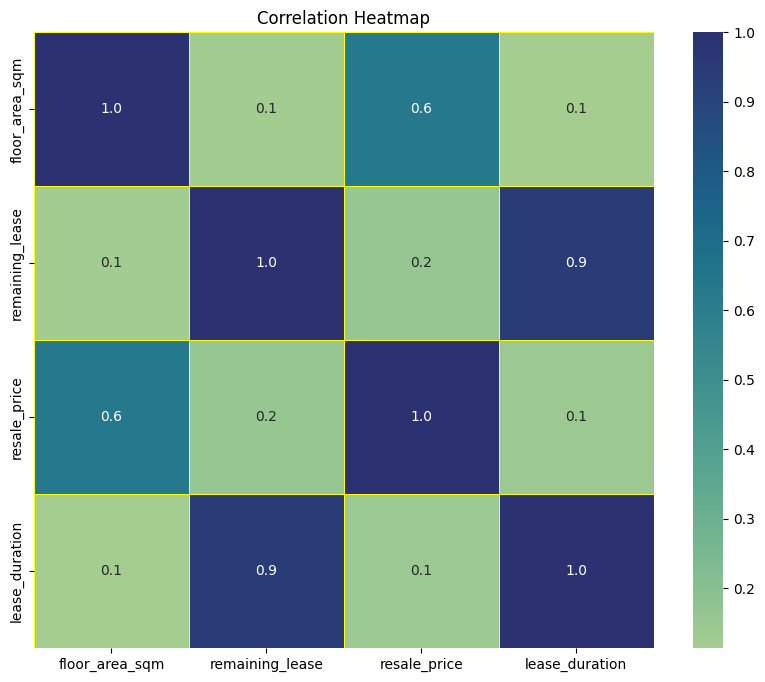

In [257]:
plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(),annot=True,cmap='crest',fmt=".1f",linewidth = .5,linecolor='yellow')
plt.title('Correlation Heatmap')
plt.show()

In [258]:
df.head(2)

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,ANG MO KIO,2 ROOM,44.0,5.11,232000.0,52.10
1,ANG MO KIO,3 ROOM,67.0,5.05,250000.0,52.04


In [259]:
town_list = df['town'].unique().tolist()
print(town_list)

['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']


In [260]:
town_list_encoded = {col : i for i,col in enumerate(town_list,1) }
print(town_list_encoded)

{'ANG MO KIO': 1, 'BEDOK': 2, 'BISHAN': 3, 'BUKIT BATOK': 4, 'BUKIT MERAH': 5, 'BUKIT PANJANG': 6, 'BUKIT TIMAH': 7, 'CENTRAL AREA': 8, 'CHOA CHU KANG': 9, 'CLEMENTI': 10, 'GEYLANG': 11, 'HOUGANG': 12, 'JURONG EAST': 13, 'JURONG WEST': 14, 'KALLANG/WHAMPOA': 15, 'MARINE PARADE': 16, 'PASIR RIS': 17, 'PUNGGOL': 18, 'QUEENSTOWN': 19, 'SEMBAWANG': 20, 'SENGKANG': 21, 'SERANGOON': 22, 'TAMPINES': 23, 'TOA PAYOH': 24, 'WOODLANDS': 25, 'YISHUN': 26}


In [261]:
flat_type = df['flat_type'].unique().tolist()
flat_type

['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE']

In [262]:
flat_type_encoded = { col : i for i,col in enumerate(flat_type,1)}
flat_type_encoded

{'2 ROOM': 1, '3 ROOM': 2, '4 ROOM': 3, '5 ROOM': 4, 'EXECUTIVE': 5}

In [263]:
df.head(2)

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,ANG MO KIO,2 ROOM,44.0,5.11,232000.0,52.10
1,ANG MO KIO,3 ROOM,67.0,5.05,250000.0,52.04


In [264]:
df['town'] = df['town'].map(town_list_encoded)

In [265]:
df['town']

0         1
1         1
2         1
3         1
4         1
         ..
49995    21
49996    21
49997    21
49998    21
49999    21
Name: town, Length: 41813, dtype: int64

In [266]:
df['flat_type'] = df['flat_type'].map(flat_type_encoded)

In [267]:
df['flat_type']

0        1
1        2
2        2
3        2
4        2
        ..
49995    4
49996    4
49997    4
49998    4
49999    4
Name: flat_type, Length: 41813, dtype: int64

In [268]:
df.head()

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,1,1,44.0,5.11,232000.0,52.10
1,1,2,67.0,5.05,250000.0,52.04
2,1,2,67.0,5.20,262000.0,52.20
3,1,2,68.0,5.17,265000.0,52.17
4,1,2,67.0,5.20,265000.0,52.20


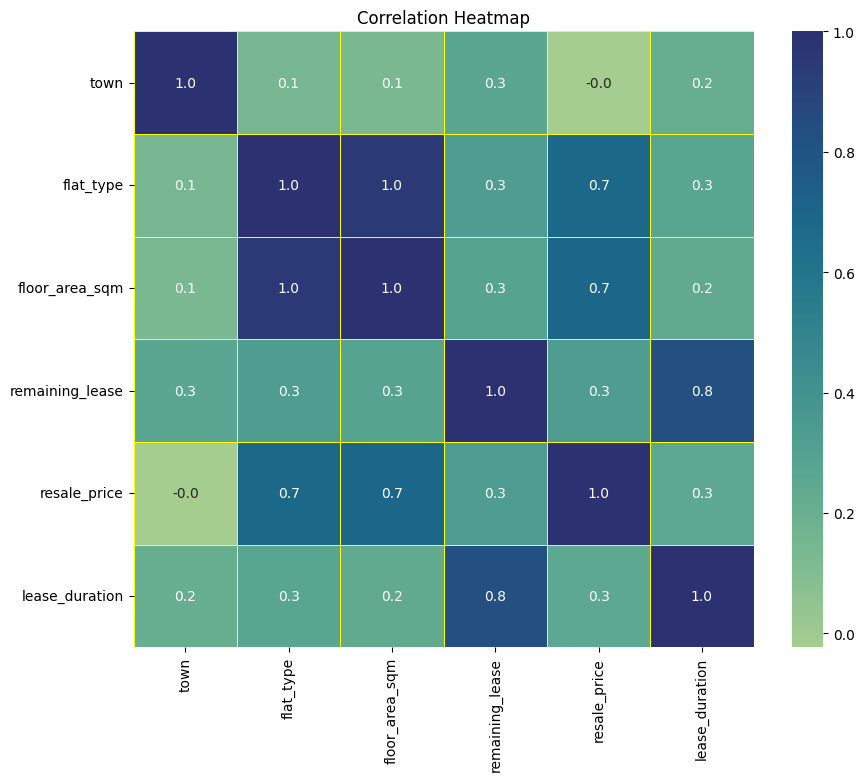

In [269]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='crest',fmt=".1f",linewidth=.5,linecolor='yellow')
plt.title("Correlation Heatmap")
plt.show()

## Model Building ##

In [270]:
df.head(2)

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,1,1,44.0,5.11,232000.0,52.10
1,1,2,67.0,5.05,250000.0,52.04


In [271]:
X = df.drop(['resale_price'],axis=1)
y = df['resale_price']

X.shape,y.shape

((41813, 5), (41813,))

In [272]:
X = df.drop(['resale_price'],axis=1)
y = df['resale_price']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = [LinearRegression(),Lasso(),Ridge(),DecisionTreeRegressor(),RandomForestRegressor(),GradientBoostingRegressor(),AdaBoostRegressor(),
          XGBRegressor()]

for model in models:

    model.fit(x_train,y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    print(f"*********{model}*********")
    print()
    print(f"Train MSE : {mean_squared_error(y_train,train_pred)}")
    print(f"Train RMSE : {root_mean_squared_error(y_train,train_pred)}")
    print(f"Train r2_score : {r2_score(y_train,train_pred)}")
    print()
    print(f"Test MSE : {mean_squared_error(y_test,test_pred)}")
    print(f"Test RMSE :{root_mean_squared_error(y_test,test_pred)}")
    print(f"Test r2_score : {r2_score(y_test,test_pred)}")

*********LinearRegression()*********

Train MSE : 5878210932.662273
Train RMSE : 76669.49153778362
Train r2_score : 0.5224344457871748

Test MSE : 5701521747.238246
Test RMSE :75508.4216974388
Test r2_score : 0.5242113833101564
*********Lasso()*********

Train MSE : 5878210953.357011
Train RMSE : 76669.49167274432
Train r2_score : 0.5224344441058649

Test MSE : 5701530646.657855
Test RMSE :75508.48062739611
Test r2_score : 0.5242106406588551
*********Ridge()*********

Train MSE : 5878210946.973996
Train RMSE : 76669.4916311175
Train r2_score : 0.5224344446244423

Test MSE : 5701512074.22075
Test RMSE :75508.3576448379
Test r2_score : 0.5242121905177437
*********DecisionTreeRegressor()*********

Train MSE : 106163429.36783248
Train RMSE : 10303.56391584157
Train r2_score : 0.9913749272416428

Test MSE : 1952573539.3521118
Test RMSE :44187.93431868152
Test r2_score : 0.8370588933167646
*********RandomForestRegressor()*********

Train MSE : 256478527.31856897
Train RMSE : 16014.9469970577

In [273]:
X = df.drop(['resale_price'],axis=1)
y = df['resale_price']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

models = [LinearRegression(),DecisionTreeRegressor(max_depth=10, random_state=42),
    RandomForestRegressor(n_estimators=100, random_state=42),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)]

for model in models:

    model.fit(x_train,y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)


    print(f"*********{model}*********")
    print()
    print(f"Train MSE : {mean_squared_error(y_train,train_pred)}")
    print(f"Train RMSE : {root_mean_squared_error(y_train,train_pred)}")
    print(f"Train r2_score : {r2_score(y_train,train_pred)}")
    print()
    print(f"Test MSE : {mean_squared_error(y_test,test_pred)}")
    print(f"Test RMSE :{root_mean_squared_error(y_test,test_pred)}")
    print(f"Test r2_score : {r2_score(y_test,test_pred)}")

*********LinearRegression()*********

Train MSE : 5850423360.205075
Train RMSE : 76488.06024606111
Train r2_score : 0.5235702124818558

Test MSE : 5812399150.806454
Test RMSE :76239.09201194918
Test r2_score : 0.5195332552602295
*********DecisionTreeRegressor(max_depth=10, random_state=42)*********

Train MSE : 2276454670.094432
Train RMSE : 47712.206720025344
Train r2_score : 0.8146166955805126

Test MSE : 2414914765.2323265
Test RMSE :49141.78227570024
Test r2_score : 0.8003773990789679
*********RandomForestRegressor(random_state=42)*********

Train MSE : 250522650.09384596
Train RMSE : 15827.907318841804
Train r2_score : 0.9795986639591653

Test MSE : 1331036163.848473
Test RMSE :36483.368318296394
Test r2_score : 0.889973383420088
*********GradientBoostingRegressor(random_state=42)*********

Train MSE : 2690071836.0576963
Train RMSE : 51865.902441369864
Train r2_score : 0.7809337419956242

Test MSE : 2769419427.9562836
Test RMSE :52625.27366158093
Test r2_score : 0.7710732000942134

In [274]:
X =df.drop(['resale_price'],axis=1)
y = df['resale_price']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = DecisionTreeRegressor()

model.fit(x_train,y_train)

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)



print(f"*********{model}*********")
print()
print(f"Train MSE : {mean_squared_error(y_train,train_pred)}")
print(f"Train RMSE : {root_mean_squared_error(y_train,train_pred)}")
print(f"Train r2_score : {r2_score(y_train,train_pred)}")
print()
print(f"Test MSE : {mean_squared_error(y_test,test_pred)}")
print(f"Test RMSE :{root_mean_squared_error(y_test,test_pred)}")
print(f"Test r2_score : {r2_score(y_test,test_pred)}")

*********DecisionTreeRegressor()*********

Train MSE : 103899828.36222251
Train RMSE : 10193.126525371032
Train r2_score : 0.9915276218156908

Test MSE : 1982871863.971575
Test RMSE :44529.449401172424
Test r2_score : 0.8369430680641605


In [275]:
X =df.drop(['resale_price'],axis=1)
y = df['resale_price']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = DecisionTreeRegressor(max_depth=5,min_samples_leaf=1,min_samples_split=2,random_state=42)

model.fit(x_train,y_train)

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)



print(f"*********{model}*********")
print()
print(f"Train MSE : {mean_squared_error(y_train,train_pred)}")
print(f"Train RMSE : {root_mean_squared_error(y_train,train_pred)}")
print(f"Train r2_score : {r2_score(y_train,train_pred)}")
print()
print(f"Test MSE : {mean_squared_error(y_test,test_pred)}")
print(f"Test RMSE :{root_mean_squared_error(y_test,test_pred)}")
print(f"Test r2_score : {r2_score(y_test,test_pred)}")

*********DecisionTreeRegressor(max_depth=5, random_state=42)*********

Train MSE : 4530928697.422526
Train RMSE : 67312.17347124164
Train r2_score : 0.6316412636232713

Test MSE : 4430025052.803158
Test RMSE :66558.43337100986
Test r2_score : 0.6313405649817068


In [276]:
X =df.drop(['resale_price'],axis=1)
y = df['resale_price']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()

model.fit(x_train,y_train)

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)



print(f"*********{model}*********")
print()
print(f"Train MSE : {mean_squared_error(y_train,train_pred)}")
print(f"Train RMSE : {root_mean_squared_error(y_train,train_pred)}")
print(f"Train r2_score : {r2_score(y_train,train_pred)}")
print()
print(f"Test MSE : {mean_squared_error(y_test,test_pred)}")
print(f"Test RMSE :{root_mean_squared_error(y_test,test_pred)}")
print(f"Test r2_score : {r2_score(y_test,test_pred)}")

*********RandomForestRegressor()*********

Train MSE : 251750092.81742343
Train RMSE : 15866.634577547422
Train r2_score : 0.9794598621491998

Test MSE : 1313326146.2151809
Test RMSE :36239.841972822964
Test r2_score : 0.8922806907146832


In [277]:
X =df.drop(['resale_price'],axis=1)
y = df['resale_price']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor(n_estimators=100, max_depth=None,random_state=42, criterion='squared_error', min_samples_split=2,min_samples_leaf=1, max_features=None, bootstrap=True)

model.fit(x_train,y_train)

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)



print(f"*********{model}*********")
print()
print(f"Train MSE : {mean_squared_error(y_train,train_pred)}")
print(f"Train RMSE : {root_mean_squared_error(y_train,train_pred)}")
print(f"Train r2_score : {r2_score(y_train,train_pred)}")
print()
print(f"Test MSE : {mean_squared_error(y_test,test_pred)}")
print(f"Test RMSE :{root_mean_squared_error(y_test,test_pred)}")
print(f"Test r2_score : {r2_score(y_test,test_pred)}")

*********RandomForestRegressor(max_features=None, random_state=42)*********

Train MSE : 250831474.86286855
Train RMSE : 15837.660018540257
Train r2_score : 0.97953641961093

Test MSE : 1293614634.811276
Test RMSE :35966.854669421344
Test r2_score : 0.8938629192274962


## Model Saving ##

In [278]:
with open("reg_model.pkl","wb") as file_1:
    pickle.dump(model,file_1)

## Loading the Model ##

In [279]:
with open("reg_model.pkl","rb") as file_1:
    new_reg_model = pickle.load(file_1)

In [280]:
df.reset_index(drop=True)

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,1,1,44.0,5.11,232000.0,52.10
1,1,2,67.0,5.05,250000.0,52.04
2,1,2,67.0,5.20,262000.0,52.20
3,1,2,68.0,5.17,265000.0,52.17
4,1,2,67.0,5.20,265000.0,52.20
...,...,...,...,...,...,...
41808,21,4,110.0,6.86,442000.0,56.18
41809,21,4,110.0,6.85,445000.0,56.18
41810,21,4,122.0,6.60,450000.0,55.92
41811,21,4,110.0,6.85,460000.0,56.18


In [281]:
X

,town,flat_type,floor_area_sqm,remaining_lease,lease_duration
0,1,1,44.0,5.11,52.10
1,1,2,67.0,5.05,52.04
2,1,2,67.0,5.20,52.20
3,1,2,68.0,5.17,52.17
4,1,2,67.0,5.20,52.20
...,...,...,...,...,...
49995,21,4,110.0,6.86,56.18
49996,21,4,110.0,6.85,56.18
49997,21,4,122.0,6.60,55.92
49998,21,4,110.0,6.85,56.18


In [290]:
df.head()

,town,flat_type,floor_area_sqm,remaining_lease,resale_price,lease_duration
0,1,1,44.0,5.11,232000.0,52.10
1,1,2,67.0,5.05,250000.0,52.04
2,1,2,67.0,5.20,262000.0,52.20
3,1,2,68.0,5.17,265000.0,52.17
4,1,2,67.0,5.20,265000.0,52.20


In [291]:
input_data =df.iloc[4].drop('resale_price').to_numpy()
re_sale_price_prediction = new_reg_model.predict([input_data])
print(f"Resale_price : {re_sale_price_prediction[0]:.2f}")

Resale_price : 285221.25


In [292]:
user_data = np.array([[1,2,67.00,5.20,52.20]])
re_sale_price_prediction = new_reg_model.predict(user_data)
print(f"Resale_price : {re_sale_price_prediction[0]:.2f}")

Resale_price : 285221.25


In [293]:
user_data = np.array([[town_list_encoded['ANG MO KIO'], flat_type_encoded['3 ROOM'], 67.00, 5.20, 52.20]])
re_sale_price_prediction = new_reg_model.predict(user_data)
print(f"Resale_price : {re_sale_price_prediction[0]:.2f}")


Resale_price : 285221.25


In [286]:
df.iloc[5]

town                    1.00
flat_type               2.00
floor_area_sqm         68.00
remaining_lease         5.12
resale_price       280000.00
lease_duration         52.12
Name: 6, dtype: float64

In [287]:
flat_type_encoded

{'2 ROOM': 1, '3 ROOM': 2, '4 ROOM': 3, '5 ROOM': 4, 'EXECUTIVE': 5}

In [288]:
print(town_list_encoded)

{'ANG MO KIO': 1, 'BEDOK': 2, 'BISHAN': 3, 'BUKIT BATOK': 4, 'BUKIT MERAH': 5, 'BUKIT PANJANG': 6, 'BUKIT TIMAH': 7, 'CENTRAL AREA': 8, 'CHOA CHU KANG': 9, 'CLEMENTI': 10, 'GEYLANG': 11, 'HOUGANG': 12, 'JURONG EAST': 13, 'JURONG WEST': 14, 'KALLANG/WHAMPOA': 15, 'MARINE PARADE': 16, 'PASIR RIS': 17, 'PUNGGOL': 18, 'QUEENSTOWN': 19, 'SEMBAWANG': 20, 'SENGKANG': 21, 'SERANGOON': 22, 'TAMPINES': 23, 'TOA PAYOH': 24, 'WOODLANDS': 25, 'YISHUN': 26}
